# MambaTab from Scratch

This notebook implements MambaTab for tabular data processing and classification/regression tasks.

## Section 1: Install and Import MambaTab

In [1]:
# Install MambaTab and required dependencies
import subprocess
import sys

# Import required libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 2: Initialize MambaTab Model

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ============================================================
# MambaTab Implementation from Scratch
# ============================================================

class SelectiveSSM(nn.Module):
    """
    Selective State Space Model (S6) - Core component of Mamba
    Implements the selective scan mechanism for sequence modeling
    """
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, dt_rank="auto"):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = int(expand * d_model)
        
        if dt_rank == "auto":
            self.dt_rank = max(d_model // 16, 1)
        else:
            self.dt_rank = dt_rank
        
        # Input projection
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        
        # Convolution for local context
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            kernel_size=d_conv,
            padding=d_conv - 1,
            groups=self.d_inner,
            bias=True
        )
        
        # SSM parameters projection
        self.x_proj = nn.Linear(self.d_inner, self.dt_rank + d_state * 2, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, self.d_inner, bias=True)
        
        # Initialize A (state transition matrix) - diagonal structure
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))
        
        # Output projection
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
    
    def forward(self, x):
        """
        x: (batch, seq_len, d_model)
        Returns: (batch, seq_len, d_model)
        """
        batch, seq_len, _ = x.shape
        
        # Input projection and split
        xz = self.in_proj(x)  # (batch, seq_len, d_inner * 2)
        x, z = xz.chunk(2, dim=-1)  # Each: (batch, seq_len, d_inner)
        
        # Convolution
        x = x.transpose(1, 2)  # (batch, d_inner, seq_len)
        x = self.conv1d(x)[:, :, :seq_len]  # Causal conv
        x = x.transpose(1, 2)  # (batch, seq_len, d_inner)
        x = F.silu(x)
        
        # SSM parameters
        x_dbl = self.x_proj(x)  # (batch, seq_len, dt_rank + d_state * 2)
        dt, B, C = torch.split(x_dbl, [self.dt_rank, self.d_state, self.d_state], dim=-1)
        
        # Delta (time step)
        dt = self.dt_proj(dt)  # (batch, seq_len, d_inner)
        dt = F.softplus(dt)
        
        # State transition matrix A
        A = -torch.exp(self.A_log)  # (d_inner, d_state)
        
        # Selective scan
        y = self.selective_scan(x, dt, A, B, C)
        
        # Skip connection with D
        y = y + x * self.D
        
        # Gate with z
        y = y * F.silu(z)
        
        # Output projection
        return self.out_proj(y)
    
    def selective_scan(self, x, dt, A, B, C):
        """
        Simplified selective scan implementation
        x: (batch, seq_len, d_inner)
        dt: (batch, seq_len, d_inner)
        A: (d_inner, d_state)
        B: (batch, seq_len, d_state)
        C: (batch, seq_len, d_state)
        """
        batch, seq_len, d_inner = x.shape
        d_state = A.shape[1]
        
        # Discretize A and B









        # dA = exp(dt * A)
        dA = torch.exp(dt.unsqueeze(-1) * A)  # (batch, seq_len, d_inner, d_state)
        dB = dt.unsqueeze(-1) * B.unsqueeze(2)  # (batch, seq_len, d_inner, d_state)
        
        # Initialize state
        h = torch.zeros(batch, d_inner, d_state, device=x.device, dtype=x.dtype)
        
        outputs = []
        for t in range(seq_len):
            # State update: h = dA * h + dB * x
            h = dA[:, t] * h + dB[:, t] * x[:, t:t+1].transpose(1, 2)
            # Output: y = C * h
            y = torch.einsum('bds,bs->bd', h, C[:, t])
            outputs.append(y)
        
        return torch.stack(outputs, dim=1)


class MambaBlock(nn.Module):
    """Single Mamba block with residual connection and layer norm"""
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.mamba = SelectiveSSM(d_model, d_state, d_conv, expand)
    
    def forward(self, x):
        return x + self.mamba(self.norm(x))


class FeatureTokenizer(nn.Module):
    """
    Tokenizes tabular features into embeddings
    Each feature gets its own embedding representation
    """
    def __init__(self, num_features, d_model):
        super().__init__()
        self.num_features = num_features
        self.d_model = d_model
        
        # Linear projection for each feature (treating each as a token)
        self.feature_embeddings = nn.Linear(1, d_model)
        
        # Learnable position embeddings for features
        self.pos_embedding = nn.Parameter(torch.randn(1, num_features, d_model) * 0.02)
        
        # Layer norm
        self.norm = nn.LayerNorm(d_model)
    
    def forward(self, x):
        """
        x: (batch, num_features)
        Returns: (batch, num_features, d_model)
        """
        batch_size = x.shape[0]
        
        # Expand features to (batch, num_features, 1)
        x = x.unsqueeze(-1)
        
        # Project each feature
        x = self.feature_embeddings(x)  # (batch, num_features, d_model)
        
        # Add positional embeddings
        x = x + self.pos_embedding
        
        return self.norm(x)


class MambaTab(nn.Module):
    """
    MambaTab: Mamba architecture for tabular data
    Uses selective state space models to capture feature interactions
    """
    def __init__(
        self, 
        num_features, 
        num_classes, 
        d_model=64, 
        d_state=16, 
        d_conv=4,
        expand=2,
        num_layers=4, 
        dropout=0.1,
        bidirectional=True
    ):
        super().__init__()
        self.num_features = num_features
        self.num_classes = num_classes
        self.bidirectional = bidirectional
        
        # Feature tokenizer
        self.tokenizer = FeatureTokenizer(num_features, d_model)
        
        # Mamba layers (forward direction)
        self.mamba_layers = nn.ModuleList([
            MambaBlock(d_model, d_state, d_conv, expand)
            for _ in range(num_layers)
        ])
        
        # Mamba layers (backward direction) for bidirectional
        if bidirectional:
            self.mamba_layers_back = nn.ModuleList([
                MambaBlock(d_model, d_state, d_conv, expand)
                for _ in range(num_layers)
            ])
        
        # Final normalization
        self.final_norm = nn.LayerNorm(d_model)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Classification head
        classifier_input_dim = d_model * 2 if bidirectional else d_model
        self.classifier = nn.Sequential(
            nn.Linear(classifier_input_dim, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )
    
    def forward(self, x):
        """
        x: (batch, num_features)
        Returns: (batch, num_classes)
        """
        # Tokenize features
        x = self.tokenizer(x)  # (batch, num_features, d_model)
        
        # Forward Mamba pass
        x_forward = x
        for layer in self.mamba_layers:
            x_forward = layer(x_forward)
        
        if self.bidirectional:
            # Backward Mamba pass (reverse sequence)
            x_backward = torch.flip(x, dims=[1])
            for layer in self.mamba_layers_back:
                x_backward = layer(x_backward)
            x_backward = torch.flip(x_backward, dims=[1])
            
            # Combine forward and backward
            x_forward = self.final_norm(x_forward)
            x_backward = self.final_norm(x_backward)
            
            # Global pooling (mean over sequence)
            x_forward_pooled = x_forward.mean(dim=1)
            x_backward_pooled = x_backward.mean(dim=1)
            
            x = torch.cat([x_forward_pooled, x_backward_pooled], dim=-1)
        else:
            x_forward = self.final_norm(x_forward)
            x = x_forward.mean(dim=1)
        
        x = self.dropout(x)
        
        return self.classifier(x)


print("MambaTab architecture implemented from scratch!")
print("\nKey components:")
print("  - SelectiveSSM: Core Mamba selective scan mechanism")
print("  - MambaBlock: Residual Mamba block with layer normalization")
print("  - FeatureTokenizer: Converts tabular features to token embeddings")
print("  - MambaTab: Full model with bidirectional processing")

MambaTab architecture implemented from scratch!

Key components:
  - SelectiveSSM: Core Mamba selective scan mechanism
  - MambaBlock: Residual Mamba block with layer normalization
  - FeatureTokenizer: Converts tabular features to token embeddings
  - MambaTab: Full model with bidirectional processing


## Section 3: Load and Prepare Data

In [ ]:
# Load data - using Bank Marketing dataset as example
df = pd.read_csv('data/bank_marketing_classification_enhanced.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset info:")
print(df.info())
print(f"\nMissing values:")
print(df.isnull().sum())

# Handle missing values
df = df.dropna()

X = df.drop(columns=['y']).values  # Convert DataFrame to NumPy array
y = df['y'].values  # Convert Series to NumPy array

# Encode categorical variables if needed
label_encoders = {}
for i in range(X.shape[1]):
    if isinstance(X[0, i], str):
        le = LabelEncoder()
        X[:, i] = le.fit_transform(X[:, i])
        label_encoders[i] = le

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target classes: {np.unique(y)}")

# Encode target if categorical
if isinstance(y[0], str):
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)
    target_classes = le_target.classes_
    print(f"Target classes: {target_classes}")

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to float32 for PyTorch
X_scaled = X_scaled.astype(np.float32)
y = y.astype(np.int64) if np.max(y) > 1 else y.astype(np.float32)

print(f"\nPreprocessing complete!")
print(f"Features shape after scaling: {X_scaled.shape}")
print(f"Target shape: {y.shape}")

Dataset shape: (45211, 64)

First few rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day_of_week  ... customer_value  reachability  \
0  unknown            5  ...              5             1   
1  unknown            5  ...              5             1   
2  unknown            5  ...              5             1   
3  unknown            5  ...              2             1   
4  unknown            5  ...              2             1   

   conversion_likelihood  financial_capacity  balance_category  \
0                      6                   2              high   
1           

## Section 4: Train MambaTab Model

In [18]:
# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train.astype(np.int64))
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val.astype(np.int64))

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Initialize MambaTab model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

input_dim = X_train.shape[1]
output_dim = len(np.unique(y_train))

# Create MambaTab model with custom hyperparameters
model = MambaTab(
    num_features=input_dim,
    num_classes=output_dim,
    d_model=64,           # Embedding dimension
    d_state=16,           # SSM state dimension
    d_conv=4,             # Convolution kernel size
    expand=2,             # Expansion factor
    num_layers=4,         # Number of Mamba blocks
    dropout=0.1,          # Dropout rate
    bidirectional=True    # Use bidirectional processing
)
model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print(f"\nModel architecture:")
print(model)

# Training configuration
num_epochs = 50
learning_rate = 0.001
weight_decay = 1e-5
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# Training loop
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0.0

print("\nTraining MambaTab model from scratch...")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        
        loss = criterion(outputs, batch_y)
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item()
        
        if output_dim > 1:
            _, predicted = torch.max(outputs.data, 1)
            train_correct += (predicted == batch_y).sum().item()
        else:
            predicted = (outputs > 0.5).squeeze()
            train_correct += (predicted == batch_y).sum().item()
        
        train_total += batch_y.size(0)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            
            if output_dim > 1:
                _, predicted = torch.max(outputs.data, 1)
                val_correct += (predicted == batch_y).sum().item()
            else:
                predicted = (outputs > 0.5).squeeze()
                val_correct += (predicted == batch_y).sum().item()
            
            val_total += batch_y.size(0)
    
    # Learning rate step
    scheduler.step()
    
    # Calculate metrics
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
    
    if (epoch + 1) % 10 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch [{epoch+1}/{num_epochs}], LR: {current_lr:.6f}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

print(f"\nTraining complete!")
print(f"Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

Training set size: (36166, 63)
Validation set size: (9042, 63)

Using device: cuda

Total parameters: 274,946
Trainable parameters: 274,946

Model architecture:
MambaTab(
  (tokenizer): FeatureTokenizer(
    (feature_embeddings): Linear(in_features=1, out_features=64, bias=True)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (mamba_layers): ModuleList(
    (0-3): 4 x MambaBlock(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mamba): SelectiveSSM(
        (in_proj): Linear(in_features=64, out_features=256, bias=False)
        (conv1d): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128)
        (x_proj): Linear(in_features=128, out_features=36, bias=False)
        (dt_proj): Linear(in_features=4, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=64, bias=False)
      )
    )
  )
  (mamba_layers_back): ModuleList(
    (0-3): 4 x MambaBlock(
      (norm): LayerNorm((64,), eps=1e-05

Epoch 1/50:   0%|          | 0/566 [00:00<?, ?it/s]

Epoch [10/50], LR: 0.000905, Train Loss: 0.2000, Val Loss: 0.2056, Train Acc: 90.84%, Val Acc: 91.05%


Epoch [20/50], LR: 0.000655, Train Loss: 0.1706, Val Loss: 0.2085, Train Acc: 92.17%, Val Acc: 91.20%


Epoch [30/50], LR: 0.000345, Train Loss: 0.1085, Val Loss: 0.3212, Train Acc: 94.91%, Val Acc: 90.07%


Epoch [40/50], LR: 0.000095, Train Loss: 0.0434, Val Loss: 0.6884, Train Acc: 97.89%, Val Acc: 89.60%


Epoch [50/50], LR: 0.000000, Train Loss: 0.0221, Val Loss: 0.9174, Train Acc: 98.97%, Val Acc: 89.48%

Training complete!
Best validation accuracy: 91.20% at epoch 20


## Section 5: Make Predictions

In [19]:
# Make predictions on training and validation data in batches to avoid OOM
model.eval()

# Predictions on training data
train_predictions_list = []
with torch.no_grad():
    for batch_X in DataLoader(X_train_tensor, batch_size=128, shuffle=False):
        batch_X = batch_X.to(device)
        train_outputs = model(batch_X)
        if output_dim > 1:
            preds = torch.argmax(train_outputs, 1).cpu().numpy()
        else:
            preds = (train_outputs > 0.5).squeeze().cpu().numpy()
        train_predictions_list.append(preds)

train_predictions = np.concatenate(train_predictions_list, axis=0)

# Predictions on validation data
val_predictions_list = []
with torch.no_grad():
    for batch_X in DataLoader(X_val_tensor, batch_size=128, shuffle=False):
        batch_X = batch_X.to(device)
        val_outputs = model(batch_X)
        if output_dim > 1:
            preds = torch.argmax(val_outputs, 1).cpu().numpy()
        else:
            preds = (val_outputs > 0.5).squeeze().cpu().numpy()
        val_predictions_list.append(preds)

val_predictions = np.concatenate(val_predictions_list, axis=0)

print(f"Train predictions shape: {train_predictions.shape}")
print(f"Validation predictions shape: {val_predictions.shape}")
print(f"\nSample predictions (first 10):")
print(f"Actual:    {y_train[:10]}")
print(f"Predicted: {train_predictions[:10]}")

Train predictions shape: (36166,)
Validation predictions shape: (9042,)

Sample predictions (first 10):
Actual:    [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predicted: [0 0 0 0 0 0 0 0 0 0]


## Section 6: Evaluate Model Performance

MODEL PERFORMANCE EVALUATION

Accuracy Metrics:
  Training Accuracy: 0.9901 (99.01%)
  Validation Accuracy: 0.8948 (89.48%)

F1-Score (weighted):
  Training F1: 0.9900
  Validation F1: 0.8934

Validation Set Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94      7985
         1.0       0.55      0.52      0.54      1057

    accuracy                           0.89      9042
   macro avg       0.75      0.73      0.74      9042
weighted avg       0.89      0.89      0.89      9042



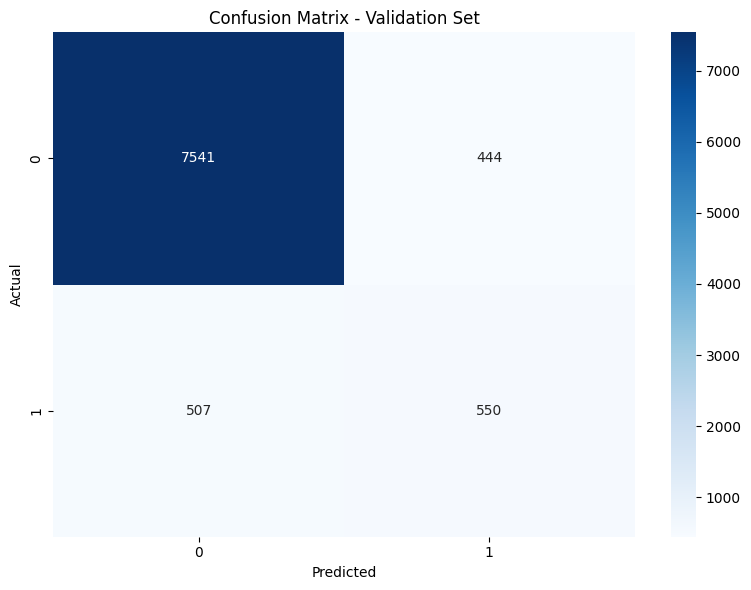

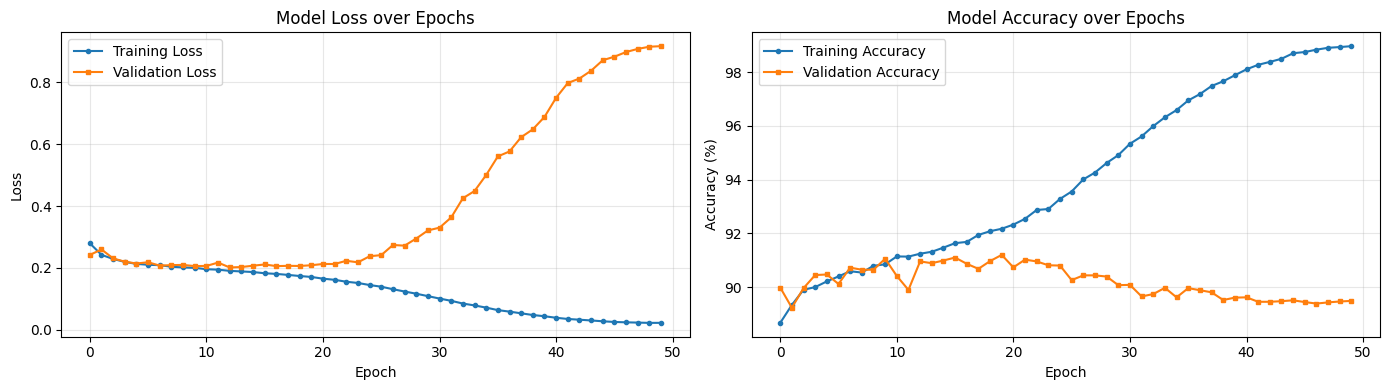


Evaluation complete!


In [20]:
# Calculate evaluation metrics
train_accuracy = accuracy_score(y_train, train_predictions)
val_accuracy = accuracy_score(y_val, val_predictions)

print("=" * 60)
print("MODEL PERFORMANCE EVALUATION")
print("=" * 60)
print(f"\nAccuracy Metrics:")
print(f"  Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

if output_dim > 1:
    train_f1 = f1_score(y_train, train_predictions, average='weighted', zero_division=0)
    val_f1 = f1_score(y_val, val_predictions, average='weighted', zero_division=0)
    print(f"\nF1-Score (weighted):")
    print(f"  Training F1: {train_f1:.4f}")
    print(f"  Validation F1: {val_f1:.4f}")
    
    print(f"\nValidation Set Classification Report:")
    print(classification_report(y_val, val_predictions, zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, val_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Validation Set')
    plt.tight_layout()
    plt.show()

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss plot
axes[0].plot(train_losses, label='Training Loss', marker='o', markersize=3)
axes[0].plot(val_losses, label='Validation Loss', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, label='Training Accuracy', marker='o', markersize=3)
axes[1].plot(val_accs, label='Validation Accuracy', marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Model Accuracy over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Evaluation complete!")

In [21]:
# Additional Metrics Evaluation for MambaTab
from sklearn.metrics import roc_auc_score, precision_score, recall_score

# Evaluate model on validation set with additional metrics in batches
model.eval()
val_logits_list = []
with torch.no_grad():
    for batch_X in DataLoader(X_val_tensor, batch_size=128, shuffle=False):
        batch_X = batch_X.to(device)
        logits = model(batch_X).cpu()
        val_logits_list.append(logits)

val_logits = torch.cat(val_logits_list, dim=0)
val_probs = F.softmax(val_logits, dim=1).numpy()
val_preds = np.argmax(val_probs, axis=1)

# Calculate metrics
if output_dim == 2:
    # Binary classification - use probability of positive class
    mamba_auc = roc_auc_score(y_val, val_probs[:, 1])
else:
    # Multi-class - use one-vs-rest
    mamba_auc = roc_auc_score(y_val, val_probs, multi_class='ovr')

mamba_f1 = f1_score(y_val, val_preds, average='macro')
mamba_acc = accuracy_score(y_val, val_preds)
mamba_precision = precision_score(y_val, val_preds, average='macro', zero_division=0)
mamba_recall = recall_score(y_val, val_preds, average='macro', zero_division=0)

print("="*70)
print("MAMBATAB VALIDATION RESULTS")
print("="*70)
print(f"Accuracy:          {mamba_acc:.4f}")
print(f"Precision (macro): {mamba_precision:.4f}")
print(f"Recall (macro):    {mamba_recall:.4f}")
print(f"F1 Score (macro):  {mamba_f1:.4f}")
print(f"ROC-AUC:           {mamba_auc:.4f}")
print("="*70)

# Create baselines dictionary for comparison
baselines = {
    'MambaTab (Scratch)': {
        'AUC': mamba_auc,
        'F1': mamba_f1,
        'Accuracy': mamba_acc
    }
}

# Summary comparison table
print("\n" + "="*70)
print("FINAL COMPARISON")
print("="*70)
print(f"{'Model':<25} {'AUC':>10} {'F1':>10} {'Accuracy':>10}")
print("-"*55)
for name, metrics in baselines.items():
    print(f"{name:<25} {metrics['AUC']:>10.4f} {metrics['F1']:>10.4f} {metrics['Accuracy']:>10.4f}")
print("="*70)

best_model_name = max(baselines.items(), key=lambda x: x[1]['AUC'])
print(f"\n✓ Best model: {best_model_name[0]} (AUC={best_model_name[1]['AUC']:.4f})")

MAMBATAB VALIDATION RESULTS
Accuracy:          0.8948
Precision (macro): 0.7452
Recall (macro):    0.7324
F1 Score (macro):  0.7385
ROC-AUC:           0.8961

FINAL COMPARISON
Model                            AUC         F1   Accuracy
-------------------------------------------------------
MambaTab (Scratch)            0.8961     0.7385     0.8948

✓ Best model: MambaTab (Scratch) (AUC=0.8961)
